In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

# VERIFICAÇÃO E LIMPEZA DE DADOS
 verificar os dados para observar se eles possuem alguma incogruencia ou se ja podem ser usados para teste

In [10]:
df = pd.read_csv("farmtech_data.csv")
df.head()

,umidade_solo,pH_solo,temperatura,chuva_mm,nitrogenio,fosforo,potassio,irrigacao_l,fertilizante_kg,produtividade_kg_ha
0,52,5.5,26,81,64,34,68,352,149,6912
1,72,5.5,23,77,64,46,64,313,105,7445
2,79,6.1,29,125,67,55,72,303,100,7840
3,72,6.0,24,77,98,40,48,347,128,7815
4,67,6.8,31,83,52,53,59,574,95,8416


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   umidade_solo         100 non-null    int64  
 1   pH_solo              100 non-null    float64
 2   temperatura          100 non-null    int64  
 3   chuva_mm             100 non-null    int64  
 4   nitrogenio           100 non-null    int64  
 5   fosforo              100 non-null    int64  
 6   potassio             100 non-null    int64  
 7   irrigacao_l          100 non-null    int64  
 8   fertilizante_kg      100 non-null    int64  
 9   produtividade_kg_ha  100 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 7.9 KB


numero de dados nulos umidade_solo           0
pH_solo                0
temperatura            0
chuva_mm               0
nitrogenio             0
fosforo                0
potassio               0
irrigacao_l            0
fertilizante_kg        0
produtividade_kg_ha    0
dtype: int64
numero de dados duplicados 0
numero de dados duplicados 0


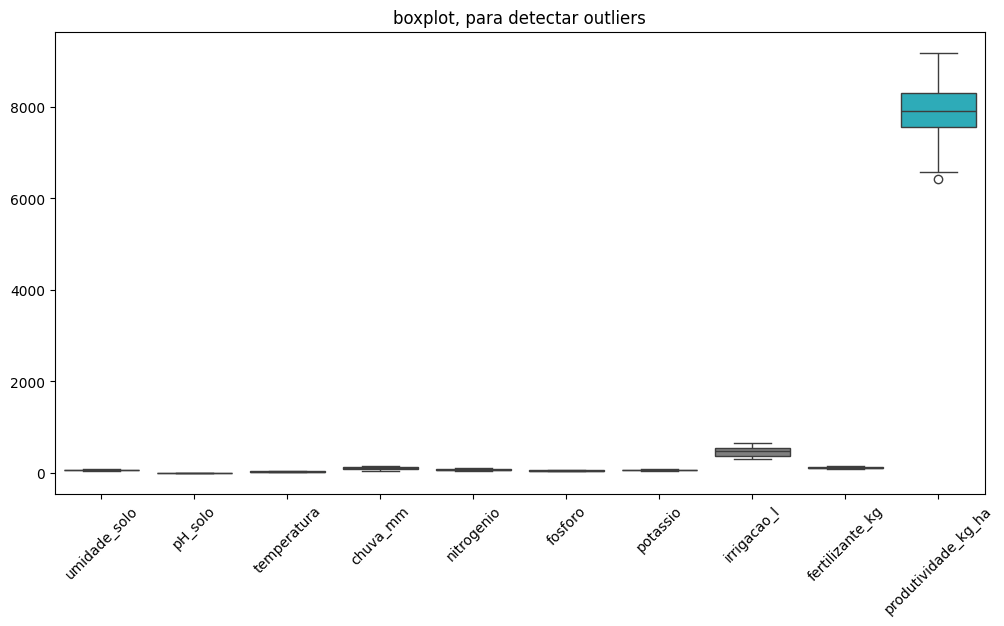

In [11]:
duplicates = df.duplicated().sum()
nulos= df.isnull().sum()
print("numero de dados nulos", nulos)
print("numero de dados duplicados", duplicates)
print("numero de dados duplicados", duplicates)
#primeiro é necessario verificar se existem duplicatas no code
#verificar a presença de outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("boxplot, para detectar outliers")
plt.xticks(rotation=45)
plt.show()

O boxplot foi utilizado para identificar possíveis outliers nas variáveis do conjunto de dados agrícola. Observa-se que a maioria das variáveis apresenta distribuição consistente, sem valores extremos significativos. Entretanto, foram identificados alguns possíveis outliers nas variáveis de irrigação e produtividade, que podem representar condições específicas de cultivo ou registros atípicos. A variável produtividade apresentou maior dispersão dos dados, indicando variação considerável entre as amostras e reforçando sua relação com os demais fatores analisados. Esses resultados sugerem que a base possui boa qualidade para a construção de modelos preditivos de produtividade agrícola.

In [26]:
#verificação de valores maximos
df.max()


,0
umidade_solo,80.0
pH_solo,7.0
temperatura,32.0
chuva_mm,157.0
nitrogenio,100.0
fosforo,60.0
potassio,75.0
irrigacao_l,647.0
fertilizante_kg,150.0
produtividade_kg_ha,9189.0


In [27]:
#verificação dos valores minimos
df.min()

,0
umidade_solo,45.0
pH_solo,5.5
temperatura,22.0
chuva_mm,50.0
nitrogenio,50.0
fosforo,30.0
potassio,45.0
irrigacao_l,300.0
fertilizante_kg,80.0
produtividade_kg_ha,6434.0


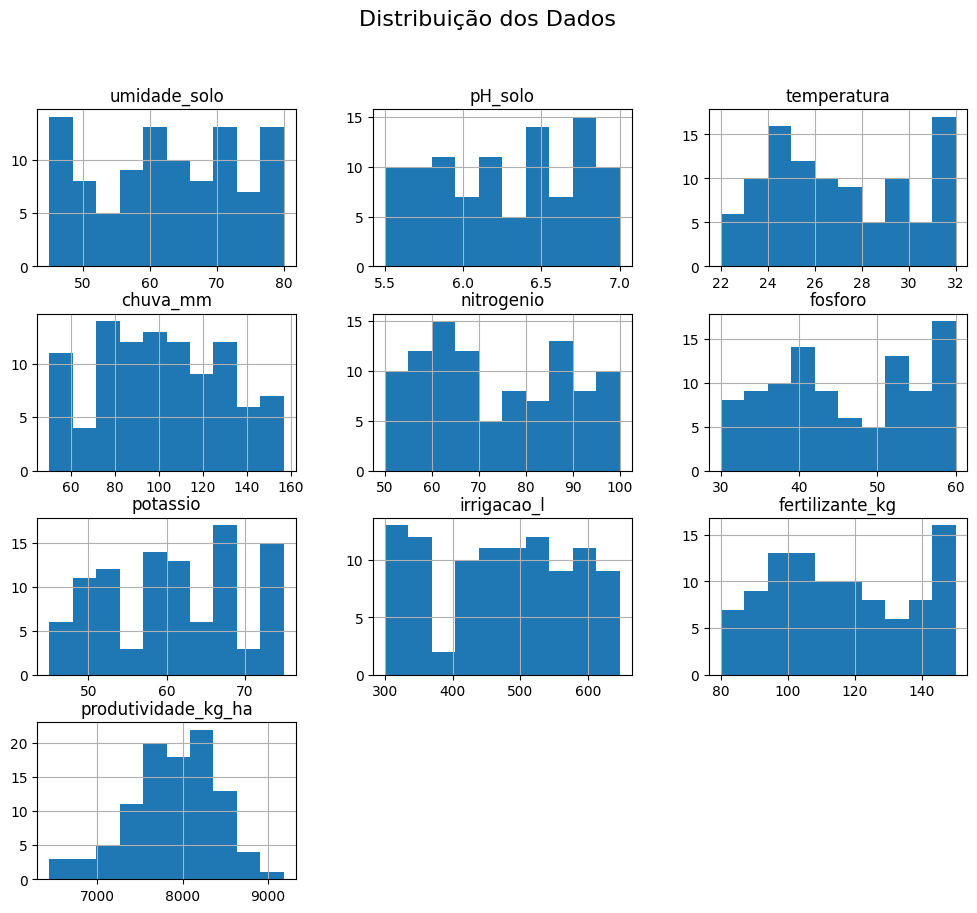

In [12]:
df.hist(figsize=(12,10))

plt.suptitle("Distribuição dos Dados", fontsize=16)

plt.show()

Os histogramas foram utilizados para analisar a distribuição das variáveis do conjunto de dados agrícola. Observa-se que todas as variáveis apresentam boa dispersão ao longo de suas respectivas faixas, sem concentração excessiva de valores em intervalos específicos. A variável produtividade_kg_ha, utilizada como alvo do modelo de regressão, apresenta distribuição próxima da normalidade, concentrando-se entre 7500 e 8500 kg/ha. Essa característica é favorável para o treinamento de modelos preditivos, pois reduz a influência de valores extremos e melhora a capacidade de generalização do algoritmo. De forma geral, os dados apresentam diversidade suficiente para representar diferentes condições agrícolas e apoiar a construção de um modelo robusto de previsão de produtividade.

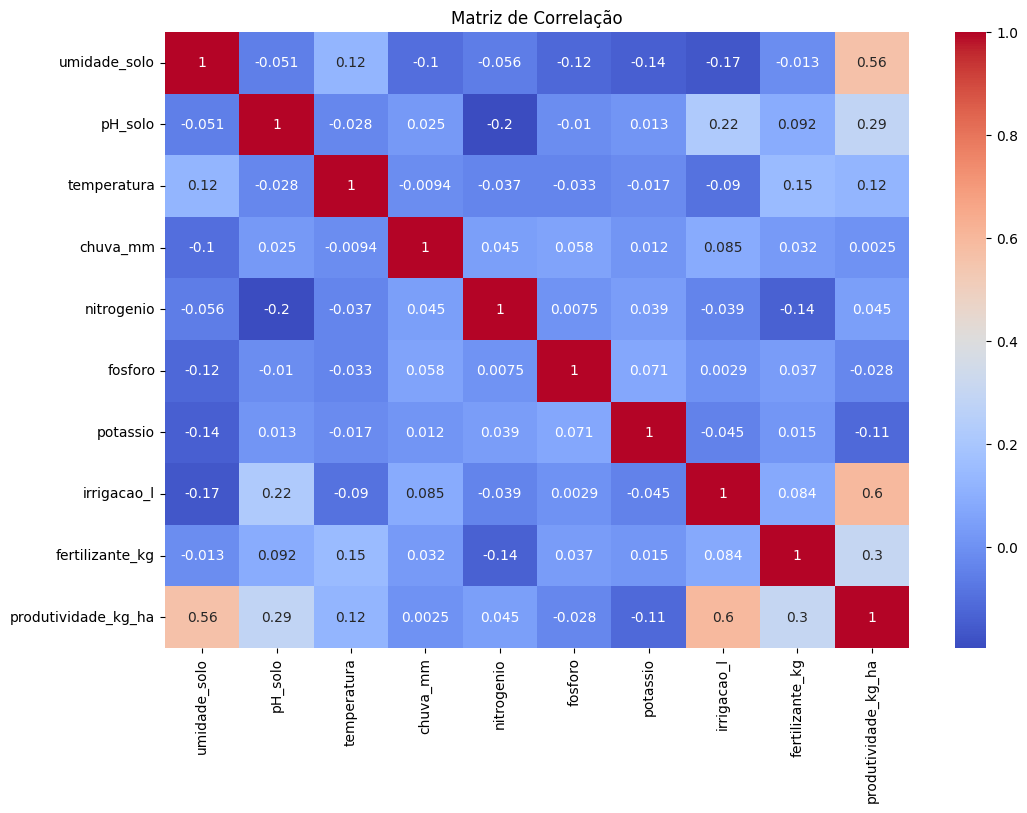

In [28]:
 #Correlação entre as features numéricas
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
#aqui na parte de cima faz considerar como numéricas todas as colunas que sejam inteiras ou decimais
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=numerics).corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

no grafico de matriz de correção podemos verificar uma coreelção proxíma entre a produtividade e a umidade do solo e entre a produtividade e a irrigação podendo nos indicar que essas variaveis podem ser de extrema importancia para a produtividade

In [11]:
X = df.drop("produtividade_kg_ha", axis=1)
y = df["produtividade_kg_ha"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr) ** 0.5)
print("R²:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 162.95423498582227
RMSE: 193.40292032596733
R²: 0.8533584909971001


In [12]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", mean_squared_error(y_test, y_pred_dt) ** 0.5)
print("R²:", r2_score(y_test, y_pred_dt))

Decision Tree
MAE: 321.6
RMSE: 416.6992920560341
R²: 0.31926764768317684


In [16]:
#Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("random forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf) ** 0.5)
print("R²:", r2_score(y_test, y_pred_rf))


random forest
MAE: 249.37249999999995
RMSE: 297.7816089603251
R²: 0.6523625062090631


In [14]:

# SVR Linear
# célula 1
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_scaled, y_train)
y_pred_svr_linear = svr_linear.predict(X_test_scaled)

print("SVR Linear")
print("MAE:", mean_absolute_error(y_test, y_pred_svr_linear))
print("RMSE:", mean_squared_error(y_test, y_pred_svr_linear) ** 0.5)
print("R²:", r2_score(y_test, y_pred_svr_linear))

# SVR Poly
svr_poly = SVR(kernel='poly')
svr_poly.fit(X_train_scaled, y_train)
y_pred_svr_poly = svr_poly.predict(X_test_scaled)

print("SVR Poly")
print("MAE:", mean_absolute_error(y_test, y_pred_svr_poly))
print("RMSE:", mean_squared_error(y_test, y_pred_svr_poly) ** 0.5)
print("R²:", r2_score(y_test, y_pred_svr_poly))

# SVR RBF
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train_scaled, y_train)
y_pred_svr_rbf = svr_rbf.predict(X_test_scaled)

print("SVR RBF")
print("MAE:", mean_absolute_error(y_test, y_pred_svr_rbf))
print("RMSE:", mean_squared_error(y_test, y_pred_svr_rbf) ** 0.5)
print("R²:", r2_score(y_test, y_pred_svr_rbf))

SVR Linear
MAE: 408.19973039946365
RMSE: 504.71409486561674
R²: 0.0013306242319008899
SVR Poly
MAE: 302.2355388578137
RMSE: 377.35405070596
R²: 0.4417497855251783
SVR RBF
MAE: 409.1401942664291
RMSE: 506.35308693888965
R²: -0.005165999781546082


O modelo de Regressão Linear apresentou o melhor desempenho entre os modelos avaliados, obtendo MAE de 162,95 kg/ha, RMSE de 193,40 kg/ha e coeficiente de determinação (R²) de 0,853. Isso indica que o modelo consegue explicar aproximadamente 85,3% da variação da produtividade agrícola, demonstrando elevada capacidade preditiva. Além disso, os baixos valores de MAE e RMSE mostram que as previsões ficaram próximas dos valores reais observados, tornando a Regressão Linear uma alternativa eficiente para estimar a produtividade com base nas variáveis do conjunto de dados.


# DASBOARD DE PREVISAO E ESTATISTICAS

In [ ]:
#DASHBOARD
st.title("🌱 FarmTech Analytics")
st.write("Análise de Dados e Predição Inteligente da Produtividade Rural")

umidade_media = df["umidade_solo"].mean()
ph_media = df["pH_solo"].mean()
prod_media = df["produtividade_kg_ha"].mean()

col1, col2, col3 = st.columns(3)

col1.metric("média da umidade",umidade_media)
col2.metric("ph médio do solo", f"{ph_media:.1f}")
col3.metric("produtividade média Kg/Ha",f"{prod_media:.0f}kg/ha")


#GRAFICO 1

# matriz de correlação
corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlação entre Variáveis"
)

fig.update_layout(
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

#GRAFICO 2 UMIDADE X PRODUTIVIDADE

fig = px.scatter(
    df,
    x="umidade_solo",
    y="produtividade_kg_ha",
    title="Relação entre Umidade do Solo e Produtividade",
    trendline="ols"  # adiciona linha de tendência
)

fig.update_layout(
    xaxis_title="Umidade do Solo (%)",
    yaxis_title="Produtividade (kg/ha)",
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

#GRAFICO 3 PH X PRODUTIVIDADE

fig = px.scatter(
    df,
    x="pH_solo",
    y="produtividade_kg_ha",
    title="Relação entre PH do Solo e Produtividade",
    trendline="ols"  # adiciona linha de tendência
)

fig.update_layout(
    xaxis_title="PH do solo (%)",
    yaxis_title="Produtividade (kg/ha)",
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

#GRAFICO 4 produtividade por faixa de umidade
df["faixa_umidade"] = pd.cut(
    df["umidade_solo"],
    bins=5
).astype(str)

fig = px.box(
    df,
    x="faixa_umidade",
    y="produtividade_kg_ha",
    title="Produtividade por Faixa de Umidade"
)

fig.update_layout(
    xaxis_title="Faixa de Umidade do Solo",
    yaxis_title="Produtividade (kg/ha)",
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

st.title("PREVER DADOS DE PRODUTIVIDADE")
st.write("insira dados para que nossa machine learning treinada possa prever a pordutividade")
umidade_solo = st.number_input("Umidade do solo (%)")
pH_solo = st.number_input("pH do solo")
temperatura = st.number_input("Temperatura (°C)")
chuva_mm = st.number_input("Chuva (mm)")
nitrogenio = st.number_input("Nitrogênio")
fosforo = st.number_input("Fósforo")
potassio = st.number_input("Potássio")
irrigacao_l = st.number_input("Irrigação (L)")
fertilizante_kg = st.number_input("Fertilizante (kg)")

if st.button("Prever produtividade"):

    dados_novos = pd.DataFrame({
        "umidade_solo": [umidade_solo],
        "pH_solo": [pH_solo],
        "temperatura": [temperatura],
        "chuva_mm": [chuva_mm],
        "nitrogenio": [nitrogenio],
        "fosforo": [fosforo],
        "potassio": [potassio],
        "irrigacao_l": [irrigacao_l],
        "fertilizante_kg": [fertilizante_kg]
    })

    dados_scaled = scaler.transform(dados_novos)

    produtividade_prevista = lr.predict(dados_scaled)

    st.success(f"Produtividade prevista: {produtividade_prevista[0]:.2f} kg/ha")

    if umidade_solo < 30:
        st.error("Recomendação: aumentar a irrigação.")
    elif pH_solo < 5.5:
        st.warning("Recomendação: corrigir a acidez do solo.")
    elif nitrogenio < 30 or fosforo < 20 or potassio < 20:
        st.warning("Recomendação: revisar fertilização do solo.")
    elif produtividade_prevista[0] < 2500:
        st.warning("Recomendação: revisar manejo agrícola.")
    else:
        st.success("Condições adequadas para boa produtividade.")